In [1]:
import torch # import, 버전 확인
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)

torch: 2.7.1+cu118
numpy: 2.2.6
matplotlib: 3.10.3


In [2]:
!pip install mecab-python3 # mecab 설치
!pip install mecab-ko-dic

In [3]:
import MeCab # mecab 래퍼 함수, 테스트

mecab = MeCab.Tagger()

def mecab_morphs(text):
    parsed = mecab.parse(text)
    return [line.split('\t')[0] for line in parsed.split('\n') if line not in ('EOS', '')]

# 테스트
print(mecab_morphs("자연어처리가 너무 재밌어서 밥먹는것도 까먹어요"))

['자연어', '처리', '가', '너무', '재밌', '어서', '밥', '먹', '는', '것', '도', '까먹', '어요']


In [4]:
!pip install sentencepiece # sentencepiece 설치

In [5]:
import sentencepiece as spm # import 테스트
print("sentencepiece 준비 완료")

sentencepiece 준비 완료


In [6]:
# 한국어-영어 병렬 코퍼스 다운로드
!wget https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
!tar -xzvf korean-english-park.train.tar.gz

--2026-06-15 05:22:27--  https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz [following]
--2026-06-15 05:22:28--  https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8718893 (8.3M) [application/octet-stream]
Saving to: ‘korean-english-park.train.tar.gz.1’

korean

In [7]:
import os # 다운받은 데이터 확인

path_to_file = "korean-english-park.train.ko"

with open(path_to_file, "r") as f:
    raw = f.read().splitlines()

print("Data Size:", len(raw))
print("Example:")
for sen in raw[0:100][::20]:
    print(">>", sen)

Data Size: 94123
Example:
>> 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
>> 북한의 핵무기 계획을 포기하도록 하려는 압력이 거세지고 있는 가운데, 일본과 북한의 외교관들이 외교 관계를 정상화하려는 회담을 재개했다.
>> "경호 로보트가 침입자나 화재를 탐지하기 위해서 개인적으로, 그리고 전문적으로 사용되고 있습니다."
>> 수자원부 당국은 논란이 되고 있고, 막대한 비용이 드는 이 사업에 대해 내년에 건설을 시작할 계획이다.
>> 또한 근력 운동은 활발하게 걷는 것이나 최소한 20분 동안 뛰는 것과 같은 유산소 활동에서 얻는 운동 효과를 심장과 폐에 주지 않기 때문에, 연구학자들은 근력 운동이 심장에 큰 영향을 미치는지 여부에 대해 논쟁을 해왔다.


문장의 최단 길이: 1
문장의 최장 길이: 377
문장의 평균 길이: 60


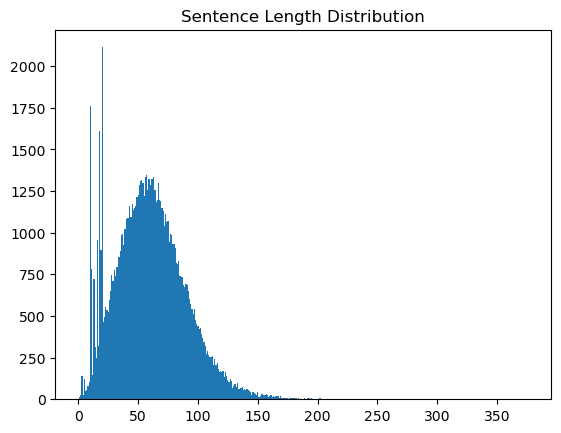

In [8]:
min_len = 999
max_len = 0
sum_len = 0

for sen in raw:
    length = len(sen)
    if min_len > length: min_len = length
    if max_len < length: max_len = length
    sum_len += length

print("문장의 최단 길이:", min_len)
print("문장의 최장 길이:", max_len)
print("문장의 평균 길이:", sum_len // len(raw))

# 길이 분포 그래프
sentence_length = np.zeros((max_len), dtype=int)
for sen in raw:
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

문장 길이 1짜리 노이즈(빈 줄, 기호 등) 발견

In [9]:
def check_sentence_with_length(raw, length):
    count = 0
    for sen in raw:
        if len(sen) == length:
            print(sen)
            count += 1
            if count > 100: return

check_sentence_with_length(raw, 1)

’


노이즈는 쉼표였음

In [10]:
min_len = 999
max_len = 0
sum_len = 0

# set으로 중복 제거 (같은 문장 하나만 남김)
cleaned_corpus = list(set(raw))
print("중복 제거 후 Data Size:", len(cleaned_corpus))

for sen in cleaned_corpus:
    length = len(sen)
    if min_len > length: min_len = length
    if max_len < length: max_len = length
    sum_len += length

print("최단 길이:", min_len)
print("최장 길이:", max_len)
print("평균 길이:", sum_len // len(cleaned_corpus))

중복 제거 후 Data Size: 77591
최단 길이: 1
최장 길이: 377
평균 길이: 64


중복 제거로 Data size가 94123에서 77591로 감소

필터링 후 Data Size: 76908


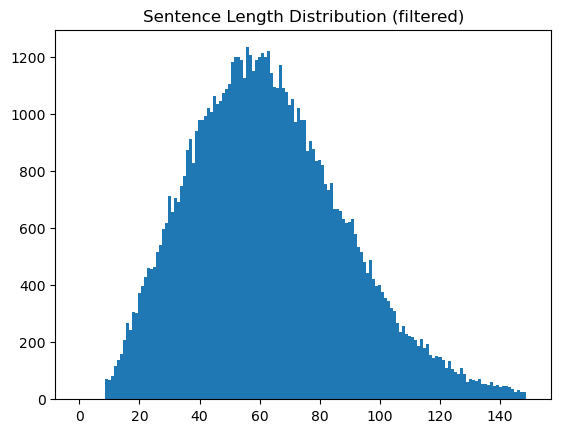

In [11]:
max_len = 150
min_len = 10

# 길이 조건 맞는 문장만 선택 (10 이상 150 미만)
filtered_corpus = [s for s in cleaned_corpus if (len(s) < max_len) & (len(s) >= min_len)]

print("필터링 후 Data Size:", len(filtered_corpus))

# 분포 다시 확인
sentence_length = np.zeros((max_len), dtype=int)
for sen in filtered_corpus:
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution (filtered)")
plt.show()

길이 10 미만(노이즈로 취급), 150 이상(패딩시 메모리 폭증) 제거
Data size 77597에서 76908로 감소

In [12]:
import torch
from torch.nn.utils.rnn import pad_sequence

# 공백 기반 토크나이저
class Tokenizer:
    def __init__(self, filters=''):
        self.word_index = {}   # {단어: 번호} 사전
        self.index_word = {}   # {번호: 단어} 역사전 (디코딩용)
        self.filters = filters

    # 코퍼스 전체를 훑어 단어사전을 구축
    def fit_on_texts(self, corpus):
        for sentence in corpus:
            # 문자열이면 공백으로 자름, 이미 리스트면 그대로
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            for token in tokens:
                # 처음 보는 단어만 사전에 등록 (번호는 1부터 차례로)
                if token not in self.word_index:
                    self.word_index[token] = len(self.word_index) + 1
        # 단어→번호 사전을 뒤집어 번호→단어 역사전 생성
        self.index_word = {idx: word for word, idx in self.word_index.items()}

    # 문장(글자) → 숫자 시퀀스로 변환 (인코딩)
    def texts_to_sequences(self, corpus):
        sequences = []
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            # 각 단어를 번호로. 사전에 없는 단어는 0으로 처리
            seq = [self.word_index.get(token, 0) for token in tokens]
            sequences.append(torch.tensor(seq, dtype=torch.long))
        return sequences

    # 숫자 시퀀스 → 문장으로 복원 (디코딩)
    def sequences_to_texts(self, sequences):
        texts = []
        for seq in sequences:
            # 텐서면 리스트로 변환
            if isinstance(seq, torch.Tensor):
                seq = seq.tolist()
            # 번호를 단어로 되돌림. 0(패딩)은 건너뜀
            tokens = [self.index_word.get(idx, "") for idx in seq if idx != 0]
            texts.append(tokens)
        return texts

print("Tokenizer 클래스 정의 완료")

Tokenizer 클래스 정의 완료


In [14]:
# 코퍼스를 받아 토큰화 + 단어사전 + 패딩된 텐서까지 한 번에
def tokenize(corpus):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(corpus)                      # 단어사전 구축
    sequences = tokenizer.texts_to_sequences(corpus)    # 숫자로 변환
    # 길이 맞춰 패딩 (0으로 채움)
    tensor = pad_sequence(sequences, batch_first=True, padding_value=0)
    return tensor, tokenizer

# 정제된 데이터를 공백 기준으로 토큰화
split_corpus = []
for kor in filtered_corpus:
    split_corpus.append(kor.split())   # 공백으로 자르기

split_tensor, split_tokenizer = tokenize(split_corpus)
print("Split(공백) Vocab Size:", len(split_tokenizer.index_word))

Split(공백) Vocab Size: 238305


In [15]:
# Mecab으로 형태소 분석하는 함수
def mecab_split(sentence):
    return mecab_morphs(sentence)   # 위에서 만든 mecab_morphs 사용

# 정제된 데이터를 형태소 기준으로 토큰화
mecab_corpus = []
for kor in filtered_corpus:
    mecab_corpus.append(mecab_split(kor))

mecab_tensor, mecab_tokenizer = tokenize(mecab_corpus)
print("MeCab Vocab Size:", len(mecab_tokenizer.index_word))

MeCab Vocab Size: 53642


In [16]:
import sentencepiece as spm
import os

# 학습용 임시 파일 생성 (filtered_corpus를 텍스트로 저장)
temp_file = 'korean_corpus.txt'
with open(temp_file, 'w') as f:
    for row in filtered_corpus:
        f.write(str(row) + '\n')

vocab_size = 8000   # 사전 크기를 직접 지정! (공백 23만, 형태소 5만과 비교)

# SentencePiece 모델 학습
spm.SentencePieceTrainer.Train(
    '--input={} --model_prefix=korean_spm --vocab_size={}'.format(temp_file, vocab_size)
)

# 생성된 파일 확인
!ls -l korean_spm*

-rw-r--r-- 1 jovyan users 379810 Jun 15 05:44 korean_spm.model
-rw-r--r-- 1 jovyan users 146754 Jun 15 05:44 korean_spm.vocab


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=korean_corpus.txt --model_prefix=korean_spm --vocab_size=8000
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: korean_corpus.txt
  input_format: 
  model_prefix: korean_spm
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -

In [17]:
s = spm.SentencePieceProcessor()
s.Load('korean_spm.model')

# 문장 → 숫자 인코딩
test_sentence = '아버지가방에들어가신다.'
tokens_ids = s.EncodeAsIds(test_sentence)
print("인코딩(숫자):", tokens_ids)

# 문장 → 조각(piece) 보기
pieces = s.EncodeAsPieces(test_sentence)
print("조각(서브워드):", pieces)

# 숫자 → 문장 복원
decoded = s.DecodeIds(tokens_ids)
print("디코딩(복원):", decoded)

인코딩(숫자): [1246, 11, 302, 7, 3541, 11, 287, 33, 4]
조각(서브워드): ['▁아버지', '가', '방', '에', '들어', '가', '신', '다', '.']
디코딩(복원): 아버지가방에들어가신다.


SentencePiece 토큰화 테스트 결과
띄어쓰기없이 쓴 문장도 거의 형태소 수준으로 나뉨
인코딩과 디코딩 완벽 일치
사전 크기는 8000이지만 서브워드의 강점이 증명됨

In [18]:
def sp_tokenize(s, corpus):
    tensor = []
    # 각 문장을 SentencePiece로 인코딩
    for sen in corpus:
        tensor.append(s.EncodeAsIds(sen))

    # vocab 파일에서 단어사전 만들기
    with open("./korean_spm.vocab", 'r') as f:
        vocab = f.readlines()

    word_index = {}
    index_word = {}
    for idx, line in enumerate(vocab):
        word = line.split("\t")[0]
        word_index.update({word: idx})
        index_word.update({idx: word})

    # 텐서로 변환 + 패딩
    tensor = [torch.tensor(seq, dtype=torch.long) for seq in tensor]
    tensor = pad_sequence(tensor, batch_first=True, padding_value=0)

    return tensor, word_index, index_word

# 실행
sp_tensor, sp_word_index, sp_index_word = sp_tokenize(s, filtered_corpus)
print("SentencePiece Vocab Size:", len(sp_word_index))
print("텐서 shape:", sp_tensor.shape)

SentencePiece Vocab Size: 8000
텐서 shape: torch.Size([76908, 100])


In [19]:
import pandas as pd
import os

data_path = os.getenv("HOME") + '/work/sentiment_classification/data/'

# NSMC 데이터 읽기
train_data = pd.read_table(data_path + 'ratings_train.txt')
test_data = pd.read_table(data_path + 'ratings_test.txt')

print("train:", len(train_data))
print("test:", len(test_data))
train_data.head()

FileNotFoundError: [Errno 2] No such file or directory: '/home/jovyan/work/sentiment_classification/data/ratings_train.txt'

In [20]:
!find ~ -name "ratings_train.txt" 2>/dev/null

오우 노우... 감정분석 때 쓴 데이터가 어디갔지...

In [21]:
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt

--2026-06-15 06:00:29--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14628807 (14M) [text/plain]
Saving to: ‘ratings_train.txt’

ratings_train.txt   100%[===================>]  13.95M  42.4MB/s    in 0.3s    

2026-06-15 06:00:31 (42.4 MB/s) - ‘ratings_train.txt’ saved [14628807/14628807]

--2026-06-15 06:00:31--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4893335 (4.7M) [application/octet

In [23]:
import pandas as pd

# 방금 받은 파일 
train_data = pd.read_table('ratings_train.txt')
test_data = pd.read_table('ratings_test.txt')

print("train:", len(train_data))
print("test:", len(test_data))
train_data.head()

train: 150000
test: 50000


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [24]:
import numpy as np

# 결측치 제거
train_data = train_data.dropna(how='any')
test_data = test_data.dropna(how='any')

# SentencePiece로 문장을 숫자로 인코딩하는 함수
def sp_encode(sentences, max_len=50):
    encoded = []
    for sent in sentences:
        ids = s.EncodeAsIds(str(sent))   # SP 인코딩
        # 길이 맞추기 (자르거나 0으로 채움)
        if len(ids) < max_len:
            ids = ids + [0] * (max_len - len(ids))
        else:
            ids = ids[:max_len]
        encoded.append(ids)
    return torch.tensor(encoded, dtype=torch.long)

# train/test 인코딩
X_train = sp_encode(train_data['document'])
y_train = torch.tensor(train_data['label'].values, dtype=torch.long)
X_test = sp_encode(test_data['document'])
y_test = torch.tensor(test_data['label'].values, dtype=torch.long)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: torch.Size([149995, 50])
X_test shape: torch.Size([49997, 50])


In [26]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# SentencePiece 토큰을 입력받는 LSTM 분류기
class SPClassifier(nn.Module):
    def __init__(self, vocab_size=8000, embed_dim=128, hidden_dim=128, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        output, (hidden, cell) = self.lstm(x)
        return self.fc(hidden.squeeze(0))

# 데이터로더
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

model = SPClassifier(vocab_size=8000) # 사전 크기
print(model)

SPClassifier(
  (embedding): Embedding(8000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


In [30]:
import torch.optim as optim

def train_model(model, train_loader, test_loader, epochs=20):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        # 학습
        model.train()
        total_loss, tr_correct, tr_total = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            _, pred = out.max(1)                  # train 정확도용
            tr_total += y.size(0)
            tr_correct += pred.eq(y).sum().item()
        train_loss = total_loss / len(train_loader)
        train_acc = 100. * tr_correct / tr_total

        # 검증 (loss + acc 둘 다)
        model.eval()
        test_total_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                test_total_loss += criterion(out, y).item()   # test loss
                _, pred = out.max(1)
                total += y.size(0)
                correct += pred.eq(y).sum().item()
        test_loss = test_total_loss / len(test_loader)
        test_acc = 100. * correct / total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        print(f"Epoch {epoch+1}/{epochs} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.2f}% | test_loss: {test_loss:.4f} | test_acc: {test_acc:.2f}%")

    return history

model = SPClassifier(vocab_size=8000)
print("=== SentencePiece + LSTM 학습 (4개 지표) ===")
history_sp = train_model(model, train_loader, test_loader, epochs=20)

=== SentencePiece + LSTM 학습 (4개 지표) ===
Epoch 1/20 | train_loss: 0.6725 | train_acc: 58.97% | test_loss: 0.6077 | test_acc: 69.11%
Epoch 2/20 | train_loss: 0.6761 | train_acc: 54.52% | test_loss: 0.6412 | test_acc: 65.65%
Epoch 3/20 | train_loss: 0.5320 | train_acc: 74.00% | test_loss: 0.4778 | test_acc: 76.21%
Epoch 4/20 | train_loss: 0.4175 | train_acc: 80.83% | test_loss: 0.4034 | test_acc: 81.54%
Epoch 5/20 | train_loss: 0.3608 | train_acc: 84.01% | test_loss: 0.3803 | test_acc: 83.15%
Epoch 6/20 | train_loss: 0.3204 | train_acc: 86.17% | test_loss: 0.3656 | test_acc: 83.76%
Epoch 7/20 | train_loss: 0.2795 | train_acc: 88.28% | test_loss: 0.3629 | test_acc: 84.17%
Epoch 8/20 | train_loss: 0.2389 | train_acc: 90.37% | test_loss: 0.3802 | test_acc: 84.21%
Epoch 9/20 | train_loss: 0.2000 | train_acc: 92.29% | test_loss: 0.3949 | test_acc: 84.11%
Epoch 10/20 | train_loss: 0.1663 | train_acc: 93.86% | test_loss: 0.4377 | test_acc: 83.80%
Epoch 11/20 | train_loss: 0.1403 | train_acc: 95.

train_loss: 0.67 → 0.06  (계속 하락)
train_acc: 59% → 97.95%  (계속 상승, 거의 외움)
test_loss:  0.36(7ep) 최저 → 계속 상승
test_acc:  최고 84.21%(8ep) 후 정체, 하락
7~8 epoch 이후 test loss가 반등함

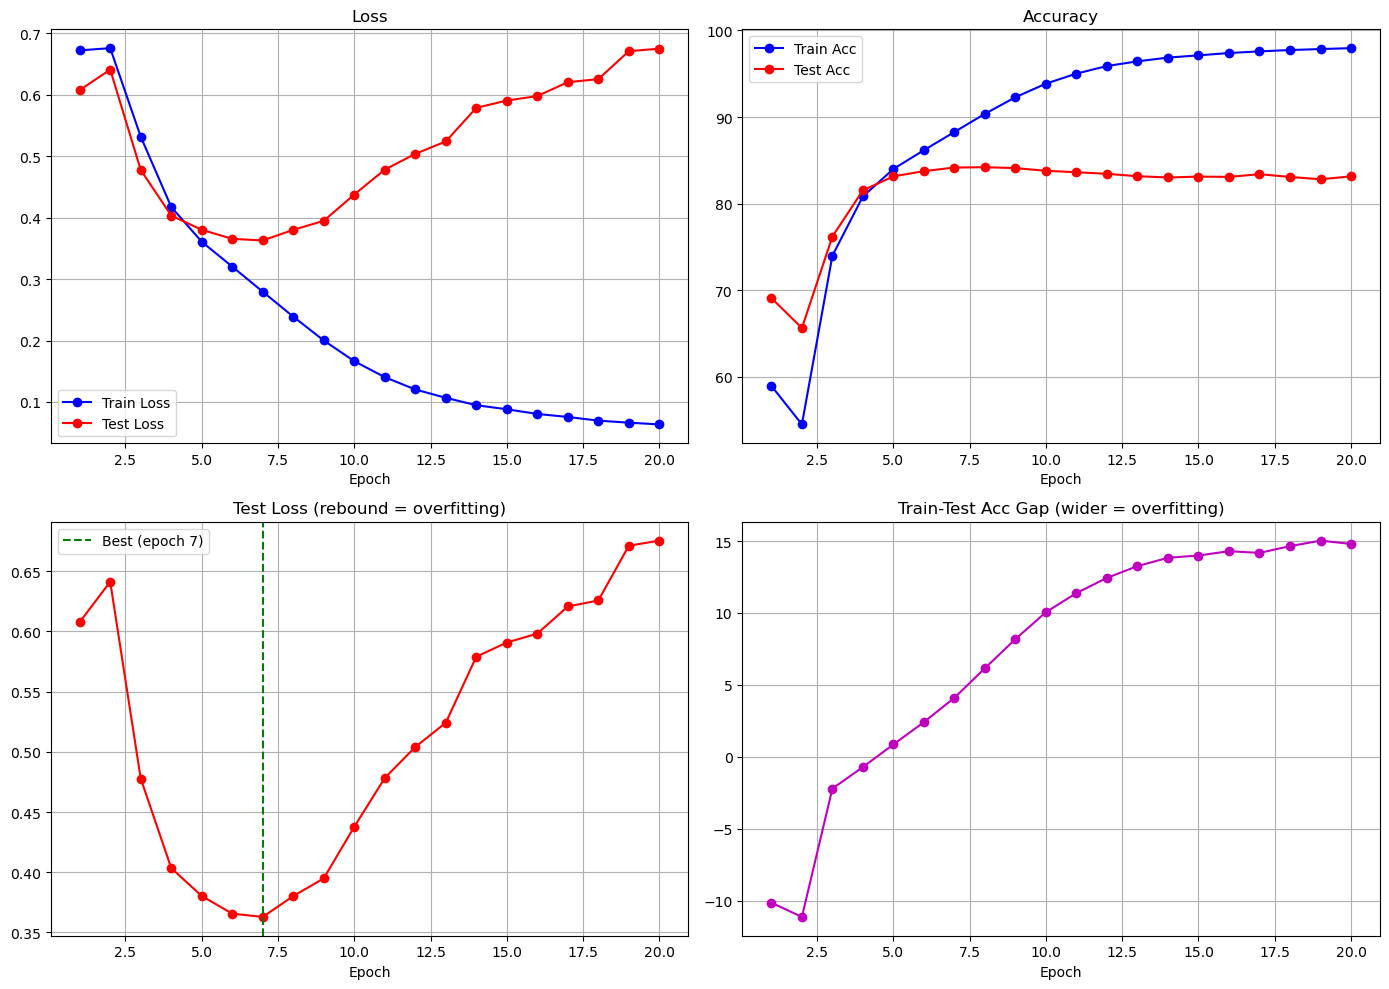

In [33]:
import matplotlib.pyplot as plt

epochs = range(1, 21)  # 1~20으로 x축 지정

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(epochs, history_sp['train_loss'], 'b-o', label='Train Loss')
axes[0,0].plot(epochs, history_sp['test_loss'], 'r-o', label='Test Loss')
axes[0,0].set_title('Loss')
axes[0,0].set_xlabel('Epoch'); axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(epochs, history_sp['train_acc'], 'b-o', label='Train Acc')
axes[0,1].plot(epochs, history_sp['test_acc'], 'r-o', label='Test Acc')
axes[0,1].set_title('Accuracy')
axes[0,1].set_xlabel('Epoch'); axes[0,1].legend(); axes[0,1].grid(True)

axes[1,0].plot(epochs, history_sp['test_loss'], 'r-o')
axes[1,0].axvline(x=7, color='green', linestyle='--', label='Best (epoch 7)')
axes[1,0].set_title('Test Loss (rebound = overfitting)')
axes[1,0].set_xlabel('Epoch'); axes[1,0].legend(); axes[1,0].grid(True)

gap = [tr - te for tr, te in zip(history_sp['train_acc'], history_sp['test_acc'])]
axes[1,1].plot(epochs, gap, 'm-o')
axes[1,1].set_title('Train-Test Acc Gap (wider = overfitting)')
axes[1,1].set_xlabel('Epoch'); axes[1,1].grid(True)

plt.tight_layout()
plt.show()

In [34]:
def run_experiment(vocab_size, model_type, name, epochs=10):
    # 1. SentencePiece 모델 학습
    spm.SentencePieceTrainer.Train(
        f'--input=korean_corpus.txt --model_prefix=spm_{name} '
        f'--vocab_size={vocab_size} --model_type={model_type}'
    )

    # 2. 학습된 SP 로드
    sp = spm.SentencePieceProcessor()
    sp.Load(f'spm_{name}.model')

    # 3. NSMC 인코딩
    def encode(sentences, max_len=50):
        out = []
        for sent in sentences:
            ids = sp.EncodeAsIds(str(sent))
            ids = ids[:max_len] + [0]*(max_len-len(ids)) if len(ids) < max_len else ids[:max_len]
            out.append(ids)
        return torch.tensor(out, dtype=torch.long)

    Xtr = encode(train_data['document'])
    Xte = encode(test_data['document'])
    ytr = torch.tensor(train_data['label'].values, dtype=torch.long)
    yte = torch.tensor(test_data['label'].values, dtype=torch.long)

    tr_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)
    te_loader = DataLoader(TensorDataset(Xte, yte), batch_size=64, shuffle=False)

    # 4. 모델 학습
    print(f"\n=== {name} (vocab={vocab_size}, type={model_type}) ===")
    m = SPClassifier(vocab_size=vocab_size)
    hist = train_model(m, tr_loader, te_loader, epochs=epochs)
    best = max(hist['test_acc'])
    print(f">>> {name} 최고 정확도: {best:.2f}%")
    return hist, best

print("실험 함수 준비 완료")

실험 함수 준비 완료


In [35]:
results = {}

# 기준은 이미 했으니 재사용 (8000, unigram = history_sp)
results['vocab8000_unigram'] = (history_sp, max(history_sp['test_acc']))

# 실험1: vocab 4000
results['vocab4000_unigram'] = run_experiment(4000, 'unigram', 'v4000', epochs=20)

# 실험2: vocab 16000
results['vocab16000_unigram'] = run_experiment(16000, 'unigram', 'v16000', epochs=20)

# 실험3: bpe
results['vocab8000_bpe'] = run_experiment(8000, 'bpe', 'bpe8000', epochs=20)

print("\n=== 전체 실험 완료 ===")
for k, (h, best) in results.items():
    print(f"{k}: {best:.2f}%")

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=korean_corpus.txt --model_prefix=spm_v4000 --vocab_size=4000 --model_type=unigram
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: korean_corpus.txt
  input_format: 
  model_prefix: spm_v4000
  model_type: UNIGRAM
  vocab_size: 4000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eo


=== v4000 (vocab=4000, type=unigram) ===
Epoch 1/20 | train_loss: 0.6761 | train_acc: 55.83% | test_loss: 0.6941 | test_acc: 49.72%
Epoch 2/20 | train_loss: 0.5463 | train_acc: 68.96% | test_loss: 0.4270 | test_acc: 80.26%
Epoch 3/20 | train_loss: 0.3931 | train_acc: 82.17% | test_loss: 0.3914 | test_acc: 82.04%
Epoch 4/20 | train_loss: 0.3527 | train_acc: 84.31% | test_loss: 0.3749 | test_acc: 83.07%
Epoch 5/20 | train_loss: 0.3194 | train_acc: 86.10% | test_loss: 0.3677 | test_acc: 83.46%
Epoch 6/20 | train_loss: 0.2878 | train_acc: 87.85% | test_loss: 0.3714 | test_acc: 83.76%
Epoch 7/20 | train_loss: 0.2538 | train_acc: 89.55% | test_loss: 0.3844 | test_acc: 83.59%
Epoch 8/20 | train_loss: 0.2205 | train_acc: 91.15% | test_loss: 0.4093 | test_acc: 83.54%
Epoch 9/20 | train_loss: 0.1880 | train_acc: 92.77% | test_loss: 0.4553 | test_acc: 83.37%
Epoch 10/20 | train_loss: 0.1598 | train_acc: 94.06% | test_loss: 0.4900 | test_acc: 83.18%
Epoch 11/20 | train_loss: 0.1388 | train_acc: 9

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=korean_corpus.txt --model_prefix=spm_v16000 --vocab_size=16000 --model_type=unigram
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: korean_corpus.txt
  input_format: 
  model_prefix: spm_v16000
  model_type: UNIGRAM
  vocab_size: 16000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1



=== v16000 (vocab=16000, type=unigram) ===
Epoch 1/20 | train_loss: 0.6723 | train_acc: 56.72% | test_loss: 0.6484 | test_acc: 64.44%
Epoch 2/20 | train_loss: 0.5556 | train_acc: 70.86% | test_loss: 0.4295 | test_acc: 80.28%
Epoch 3/20 | train_loss: 0.3811 | train_acc: 83.04% | test_loss: 0.3757 | test_acc: 83.15%
Epoch 4/20 | train_loss: 0.3315 | train_acc: 85.57% | test_loss: 0.3587 | test_acc: 84.04%
Epoch 5/20 | train_loss: 0.2919 | train_acc: 87.65% | test_loss: 0.3578 | test_acc: 84.10%
Epoch 6/20 | train_loss: 0.2513 | train_acc: 89.69% | test_loss: 0.3690 | test_acc: 84.35%
Epoch 7/20 | train_loss: 0.2096 | train_acc: 91.67% | test_loss: 0.3994 | test_acc: 84.17%
Epoch 8/20 | train_loss: 0.1711 | train_acc: 93.45% | test_loss: 0.4273 | test_acc: 83.74%
Epoch 9/20 | train_loss: 0.1401 | train_acc: 94.77% | test_loss: 0.4800 | test_acc: 83.81%
Epoch 10/20 | train_loss: 0.1158 | train_acc: 95.88% | test_loss: 0.5213 | test_acc: 83.71%
Epoch 11/20 | train_loss: 0.0995 | train_acc:

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=korean_corpus.txt --model_prefix=spm_bpe8000 --vocab_size=8000 --model_type=bpe
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: korean_corpus.txt
  input_format: 
  model_prefix: spm_bpe8000
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id


=== bpe8000 (vocab=8000, type=bpe) ===
Epoch 1/20 | train_loss: 0.6827 | train_acc: 55.51% | test_loss: 0.6744 | test_acc: 55.76%
Epoch 2/20 | train_loss: 0.5276 | train_acc: 72.27% | test_loss: 0.4299 | test_acc: 80.11%
Epoch 3/20 | train_loss: 0.3855 | train_acc: 82.54% | test_loss: 0.3858 | test_acc: 82.47%
Epoch 4/20 | train_loss: 0.3436 | train_acc: 84.86% | test_loss: 0.3725 | test_acc: 83.30%
Epoch 5/20 | train_loss: 0.3091 | train_acc: 86.65% | test_loss: 0.3714 | test_acc: 83.45%
Epoch 6/20 | train_loss: 0.2738 | train_acc: 88.54% | test_loss: 0.3817 | test_acc: 83.74%
Epoch 7/20 | train_loss: 0.2373 | train_acc: 90.36% | test_loss: 0.4060 | test_acc: 83.54%
Epoch 8/20 | train_loss: 0.2032 | train_acc: 92.04% | test_loss: 0.4243 | test_acc: 83.33%
Epoch 9/20 | train_loss: 0.1714 | train_acc: 93.54% | test_loss: 0.4618 | test_acc: 83.14%
Epoch 10/20 | train_loss: 0.1435 | train_acc: 94.79% | test_loss: 0.5128 | test_acc: 82.70%
Epoch 11/20 | train_loss: 0.1233 | train_acc: 95.

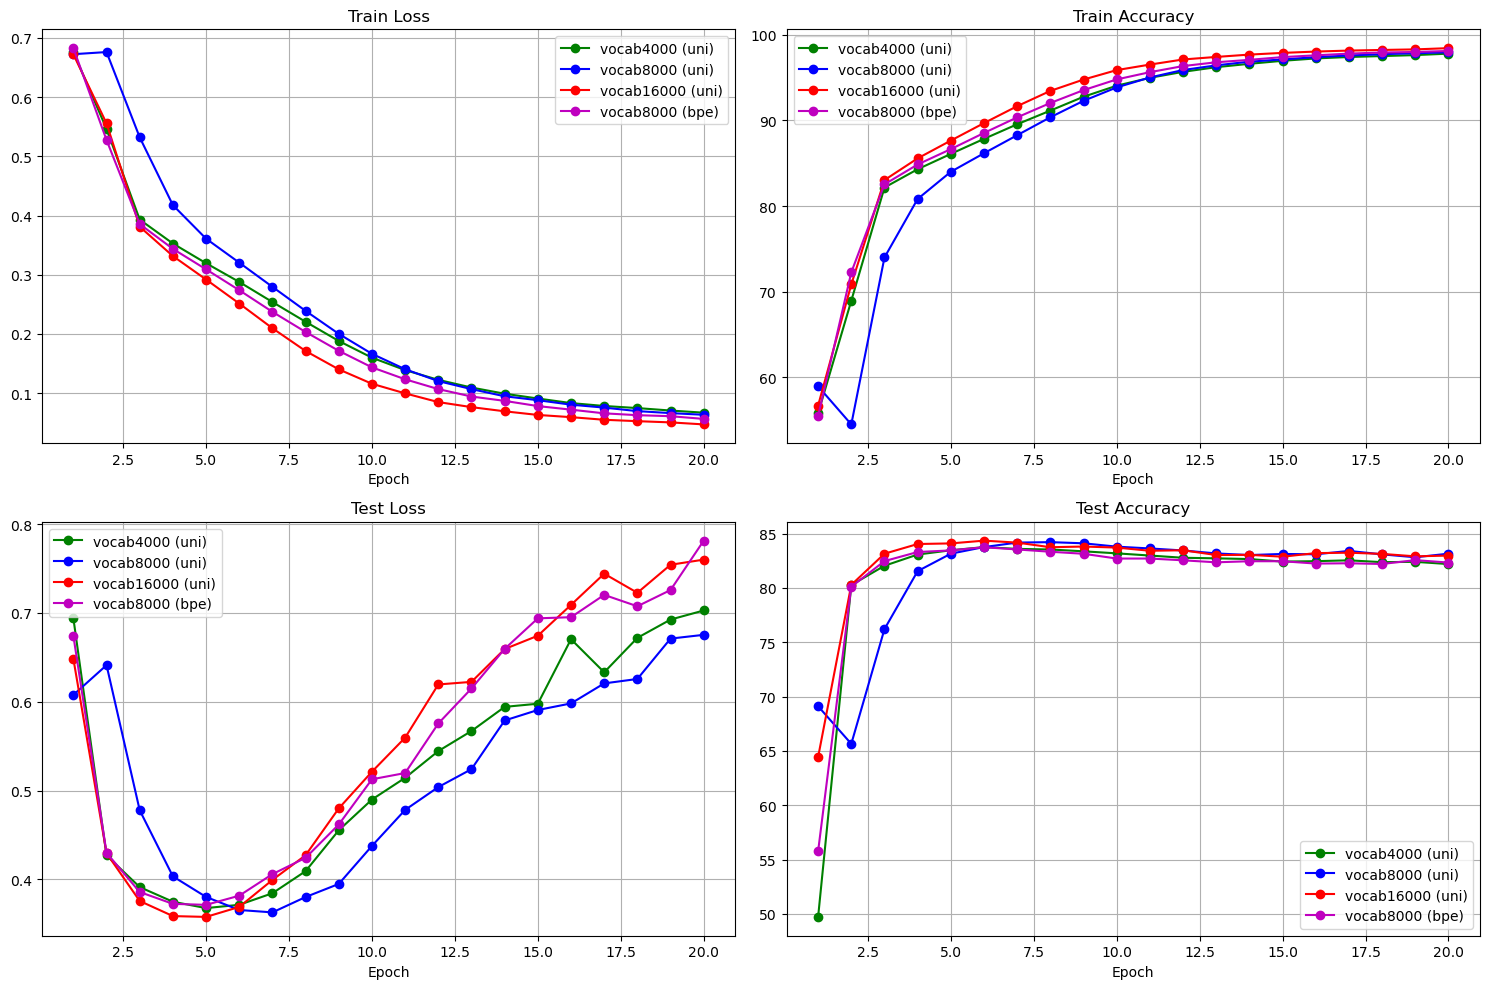

In [37]:
import matplotlib.pyplot as plt

epochs = range(1, 21)

# 실험별 (history, 색)
exps = {
    'vocab4000 (uni)': (results['vocab4000_unigram'][0], 'g'),
    'vocab8000 (uni)': (results['vocab8000_unigram'][0], 'b'),
    'vocab16000 (uni)': (results['vocab16000_unigram'][0], 'r'),
    'vocab8000 (bpe)': (results['vocab8000_bpe'][0], 'm'),
}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for name, (h, c) in exps.items():
    axes[0,0].plot(epochs, h['train_loss'], color=c, marker='o', label=name)
    axes[0,1].plot(epochs, h['train_acc'],  color=c, marker='o', label=name)
    axes[1,0].plot(epochs, h['test_loss'],  color=c, marker='o', label=name)
    axes[1,1].plot(epochs, h['test_acc'],   color=c, marker='o', label=name)

axes[0,0].set_title('Train Loss')
axes[0,1].set_title('Train Accuracy')
axes[1,0].set_title('Test Loss')
axes[1,1].set_title('Test Accuracy')

for ax in axes.flat:
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

세 가지 토큰화(공백/형태소/SentencePiece)를 비교, 한국어에서 토큰화 방식이 단어사전 크기와 효율에 미치는 영향을 확인

단어사전 크기
공백: 238305
형태소(Mecab): 53642
SentencePiece: 8000(지정)

vocab size 4000, 8000, 16000 변경해도 큰 차이는 없고 unigram 모델이 pbe 모델보다 약간 우세한 모습

4가지 모델 전부 7epoch 이후 과적합 현상 보임